In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from time import perf_counter

In [3]:
# Implement baseline algorithm
def baseline_max_sublist(arr):
    max_so_far = float('-inf')
    for i in range(len(arr)):
        current_max = 0      
        for j in range(i, len(arr)):
            current_max += arr[j]
            max_so_far = max(max_so_far, current_max)    
    return max_so_far

In [4]:
# Implement target algorithm
def kadane_max_sublist(arr):
    max_so_far = float('-inf')
    current_max = 0
    for i in range(len(arr)):
        current_max = current_max + arr[i]
        if current_max > max_so_far:
            max_so_far = current_max
        if current_max < 0:
            current_max = 0
    return max_so_far



In [ ]:
arr = np.random.randint(-100, 100, size=100)
baseline_max_sublist(arr)

np.int64(5772)

In [6]:
arr = np.random.randint(-100, 100, size=100)
kadane_max_sublist(arr)

np.int64(532)

In [7]:
start_time = perf_counter()
baseline_max_sublist([100, 500, 1000, 2500, 5000, 10000])
end_time = perf_counter()
print("Baseline times for baseline_max_sublist:", end_time - start_time)

start_time = perf_counter()
kadane_max_sublist([100, 500, 1000, 2500, 5000, 10000])
end_time = perf_counter()
print("Kadane's algorithm times for kadane_max_sublist:", end_time - start_time)

Baseline times for baseline_max_sublist: 8.54579993756488e-05
Kadane's algorithm times for kadane_max_sublist: 5.241700273472816e-05


In [8]:
def experiment(func, arr):
    arr_avg_times = []
    for j in arr:
        arr_avg = []
        for i in range(0,5):
            start_time = perf_counter()
            rand_arr = np.random.randint(-100, 100, size=j)
            func(rand_arr)
            end_time = perf_counter()
            arr_avg.append(end_time - start_time)
        arr_avg_times.append(sum(arr_avg) / len(arr_avg))
    return arr_avg_times

In [17]:
baseline_avg = experiment(baseline_max_sublist, [100, 500, 1000, 2500, 5000, 10000])
print("Baseline average times:", baseline_avg)
kadane_avg = experiment(kadane_max_sublist, [100, 500, 1000, 2500, 5000, 10000])
print("Kadane's algorithm average times:", kadane_avg)

Baseline average times: [0.0010294501960743218, 0.01190634180093184, 0.03704215840261895, 0.20563984179461842, 0.830629391601542, 3.5218767999991543]
Kadane's algorithm average times: [2.3432998568750917e-05, 4.861639754381031e-05, 0.0001174245961010456, 0.00020872479944955558, 0.0004243999981554225, 0.0008622666005976498]


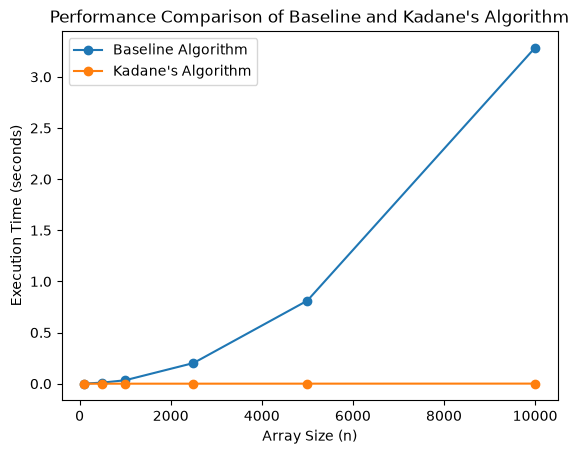

In [15]:
# Plotting the results
# Create a line plot with Array Size (n) on the x-axis and Execution Time (seconds) on the y-axis.
x = [100, 500, 1000, 2500, 5000, 10000]
plt.plot(x, baseline_avg, label='Baseline Algorithm', marker='o')
plt.plot(x, kadane_avg, label='Kadane\'s Algorithm', marker='o')
plt.legend()
plt.xlabel('Array Size (n)')
plt.ylabel('Execution Time (seconds)')
plt.title('Performance Comparison of Baseline and Kadane\'s Algorithm')
plt.show()